# Shallow regression for vector data

**Before starting with this exercise, the general [vector data preparations exercise](../01_vector_data_preparation) must be done.**

Reminder: We are within supervised learning (we have labels/targets that are real values) -> Regression

Data and goal: In this notebook we read the zip code data created in `01_data_vector_preparations` and train different machine learning models for
predicting the median income per zip-code area from population and spatial features. We will adjust parameters to improve the performance on a validation dataset and finally assesses the models error metrics with a test dataset.

Notebook contents:

0. Environment preparation
1. Reading the data
2. Function defintion
3. Lasso regression
4. Random Forest
5. Task 
6. Model comparison



## 0. Environment preparation

In [1]:
import os
import time
import pandas as pd
from math import sqrt
# machine learning models
from sklearn.linear_model import Lasso
from sklearn.ensemble import RandomForestRegressor
# error metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error,r2_score
# plots
import matplotlib.pyplot as plt


## 1. Reading the data
### 1.1 Define input and output file paths 

In [2]:
username = os.environ.get('USER')
base_directory= os.path.join('/scratch/project_462001167/students', username, 'GeoML')

# Inputs, all datasets created in 01_vector_preparation.ipynb
data_directory = os.path.join(base_directory,'data')
preprocessed_data_directory = os.path.join(data_directory,'preprocessed_regression')
scaled_train_dataset_name = os.path.join(preprocessed_data_directory,'scaled_train_zip_code_data.csv')
scaled_test_dataset_name = os.path.join(preprocessed_data_directory,'scaled_test_zip_code_data.csv')
scaled_val_dataset_name = os.path.join(preprocessed_data_directory,'scaled_val_zip_code_data.csv')
train_label_name = os.path.join(preprocessed_data_directory,'train_income_labels.pkl')
test_label_name = os.path.join(preprocessed_data_directory,'test_income_labels.pkl')
val_label_name = os.path.join(preprocessed_data_directory,'val_income_labels.pkl')

# Read also unscaled datasets
train_dataset_name = os.path.join(preprocessed_data_directory,'train_zip_code_data.csv')
test_dataset_name = os.path.join(preprocessed_data_directory,'test_zip_code_data.csv')
val_dataset_name = os.path.join(preprocessed_data_directory,'val_zip_code_data.csv')

# Outputs
results_directory = os.path.join(data_directory,'regression_results')

def create_dir(directory_name):
    if not os.path.exists(directory_name):
        os.makedirs(directory_name)
create_dir(results_directory)

metrics_filename = os.path.join(results_directory,'shallow_metrics.csv')

In [3]:
# For reproducible results when randomness is involved, we can set a random seed
random_seed = 42

### 1.2 Reading the data

In [4]:
# Read train, validation and test datasets
scaled_x_train = pd.read_csv(scaled_train_dataset_name)
scaled_x_val = pd.read_csv(scaled_val_dataset_name)
x_train = pd.read_csv(train_dataset_name)
x_val = pd.read_csv(val_dataset_name)
y_train = pd.read_pickle(train_label_name)
y_val = pd.read_pickle(val_label_name)
scaled_x_test = pd.read_csv(scaled_test_dataset_name)
x_test = pd.read_csv(test_dataset_name)
y_test = pd.read_pickle(test_label_name)

## 2. Function definitions

For the regression exercises we will generate the following erroro metrics:
Root Mean Square Error (RMSE), Mean Absolute Error (MAE), coefficient of determination (R^2).
* RMSE and MAE: related to the income value, the smaller the better, unit is Euros;
* RMSE: "punishes" larger errors more than smaller
* MAE: more intuitive interpretation, "all errors are equal"
* R^2: determines "goodness of fit", not in euros, 1 would be a perfect fit



In [5]:
# Calculating error metrics for regression predictions

def calculate_error_metrics(test_labels,label_predictions, model_name):

    #Asessing the performance of the model with root mean squared error, mean absolute error and coefficient of determination r2
    rmse = sqrt(mean_squared_error(test_labels, label_predictions))
    mae = mean_absolute_error(test_labels, label_predictions)
    r2 = r2_score(test_labels, label_predictions)

    # store them in a dictionary
    metrics_dict = dict(zip(['model','RMSE','MAE','R2'],[model_name,rmse,mae,r2]))

    return metrics_dict

def print_error_metrics(metrics_dict, model_name, dataset_name):
    print(f"\nError metrics for {model_name} on the {dataset_name} dataset: \n" +
            f"\t Root mean squared error (RMSE): {round(metrics_dict['RMSE'])} \n" +
            f"\t Mean absolute error (MAE): {round(metrics_dict['MAE'])} \n" +
            f"\t Coefficient of determination (R2): {round(metrics_dict['R2'],4)} \n")

def store_error_metrics(test_labels, label_predictions, model_name, metrics_collection = None):

    metrics_dict = calculate_error_metrics(test_labels, label_predictions, model_name)

    # in case these are the first results we want to store in that dataframe, we need to first create it
    if metrics_collection is None:
        metrics_collection = pd.DataFrame(columns=['model','RMSE','MAE','R2'])
    metrics_collection = pd.concat([metrics_collection, pd.DataFrame([metrics_dict])], ignore_index=True)
    #print_error_metrics(metrics_dict,model_name)

    return metrics_collection

# to time the model training we create a function for model training
def train_model(x_train, y_train, model):
    start_time = time.time()  
    print(model)
    model.fit(x_train,y_train)
    print('Model training took: ', round((time.time() - start_time), 2), ' seconds')
    return model

## 3. Lasso regression 

One of the simpler approaches for regression with few important features is lasso regression. Compared to any of the following models it is still easy to compute. Here, we use it with default parameters, but you can also check out others following the documentation:

* https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html

In [6]:
lasso = Lasso()
lasso_name = "Lasso Regressor"
lasso.fit(scaled_x_train, y_train)
lasso_predictions_val = lasso.predict(scaled_x_val)


# then we can get some performance metrics
print_error_metrics(calculate_error_metrics(y_val,lasso_predictions_val, lasso_name), lasso_name, 'validation')

# and store the results on the test dataset for later model comparison
lasso_predictions_test = lasso.predict(scaled_x_test)
print_error_metrics(calculate_error_metrics(y_test,lasso_predictions_test, lasso_name), lasso_name, 'test')
metrics_collection = store_error_metrics(y_test,lasso_predictions_test, lasso_name)



Error metrics for Lasso Regressor on the validation dataset: 
	 Root mean squared error (RMSE): 1779 
	 Mean absolute error (MAE): 1344 
	 Coefficient of determination (R2): 0.7109 


Error metrics for Lasso Regressor on the test dataset: 
	 Root mean squared error (RMSE): 1758 
	 Mean absolute error (MAE): 1185 
	 Coefficient of determination (R2): 0.7104 



/LUMI_TYKKY_NLzHrIC/miniconda/envs/env1/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.887e+08, tolerance: 1.932e+06
  model = cd_fast.enet_coordinate_descent(
/tmp/ipykernel_129635/2475714356.py:28: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_collection = pd.concat([metrics_collection, pd.DataFrame([metrics_dict])], ignore_index=True)


Text(0.5, 1.0, 'Actual vs predicted median income by zip-code area')

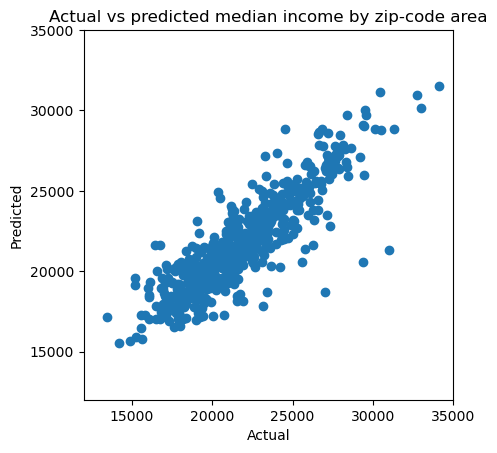

In [7]:
# visualize the regression predictions
plt.scatter(y_test, lasso_predictions_test)
plt.xlabel("Actual")
plt.ylabel("Predicted")
# make the axis scales equal
plt.xlim(12000, 35000)
plt.ylim(12000, 35000)
ax = plt.gca() 
ax.set_aspect('equal', adjustable='box')
plt.title("Actual vs predicted median income by zip-code area")

## 4. Random Forest Regressor

* https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html
* https://scikit-learn.org/stable/modules/ensemble.html#forest


In [8]:
random_forest = RandomForestRegressor(n_estimators=100, max_depth= None, max_features=None, random_state= random_seed, n_jobs=1,verbose=1,)
random_forest_name = "Random Forest Regressor"

random_forest = train_model(x_train, y_train,random_forest)
random_forest_predictions = random_forest.predict(x_val)

# then we can get some performance metrics
print_error_metrics(calculate_error_metrics(y_val,random_forest_predictions, random_forest_name), random_forest_name, 'validation')

# and store the results on the test dataset for later model comparison, after we are done optimizing the parameters
random_forest_predictions = random_forest.predict(x_test)
print_error_metrics(calculate_error_metrics(y_test,random_forest_predictions, random_forest_name), random_forest_name, 'test')
metrics_collection = store_error_metrics(y_test,random_forest_predictions, random_forest_name, metrics_collection)

RandomForestRegressor(max_features=None, n_jobs=1, random_state=42, verbose=1)


[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    3.5s


Model training took:  7.22  seconds

Error metrics for Random Forest Regressor on the validation dataset: 
	 Root mean squared error (RMSE): 1472 
	 Mean absolute error (MAE): 1105 
	 Coefficient of determination (R2): 0.8022 


Error metrics for Random Forest Regressor on the test dataset: 
	 Root mean squared error (RMSE): 1436 
	 Mean absolute error (MAE): 1036 
	 Coefficient of determination (R2): 0.8068 



[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s


Text(0.5, 1.0, 'Actual vs predicted median income by zip-code area')

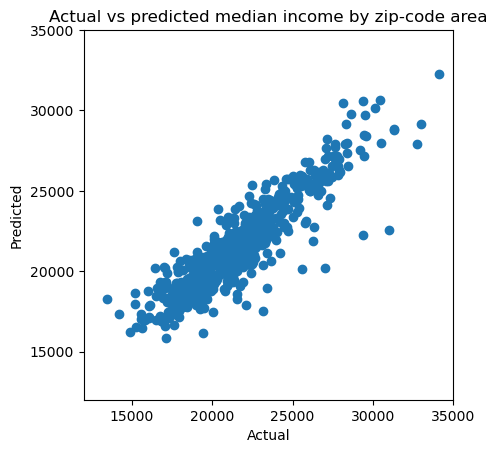

In [9]:
# visualize the regression predictions
plt.scatter(y_test, random_forest_predictions)
plt.xlabel("Actual")
plt.ylabel("Predicted")
# make the axis scales equal
plt.xlim(12000, 35000)
plt.ylim(12000, 35000)
ax = plt.gca() 
ax.set_aspect('equal', adjustable='box')
plt.title("Actual vs predicted median income by zip-code area")

In [10]:
#let's take a look at feature importances
# create dataframe of feature importance from random forest model
adf = pd.DataFrame(zip(x_train.columns, random_forest.feature_importances_), columns= ['name','importance'])
# sort the dataframe to have highest ranking features first
adf.sort_values('importance', ascending=False)

,name,importance
6,he_kika,0.459515
1,euref_y,0.097966
35,te_takk,0.079264
54,tr_hy_tul,0.043641
61,ra_as_kpa,0.031583
...,...,...
102,Kainuu,0.000091
90,tp_x_tunt,0.000073
88,tp_t_koti,0.000070
106,Kymenlaakso,0.000038


## 5. Task

Study the [scikit-learn documentation](https://scikit-learn.org/stable/supervised_learning.html#supervised-learning) to find other regression models and/or experiment with different hyperparameter values. Can you improve on the performance metrics or make the training faster?
Report the best results (on test set, see below) and mark down model and parameters used, so that others can reproduce the results. 

You can also run below cells twice to check out some other ensemble regressors:

In [11]:
# %load ada_boost.py
from sklearn.ensemble import AdaBoostRegressor
# AdaBoost Regressor

# https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.AdaBoostRegressor.html
# https://scikit-learn.org/stable/modules/ensemble.html#adaboost

ada_boost = AdaBoostRegressor(n_estimators=30, learning_rate=1.0, loss='linear', random_state=random_seed)
ada_boost_name = "AdaBoost Regressor"

ada_boost = train_model(x_train, y_train,ada_boost)
ada_boost_predictions = ada_boost.predict(x_val)

# then we can get some performance metrics
print_error_metrics(calculate_error_metrics(y_val,ada_boost_predictions, ada_boost_name), ada_boost_name, 'vaidation')

# and store the results on the test dataset for later model comparison, after we are done optimizing the parameters
#ada_boost_predictions = ada_boost.predict(x_test)
#print_error_metrics(calculate_error_metrics(y_test,ada_boost_predictions, ada_boost_name), ada_boost_name, 'test')
#metrics_collection = store_error_metrics(y_test,ada_boost_predictions, ada_boost_name, metrics_collection)

AdaBoostRegressor(n_estimators=30, random_state=42)
Model training took:  0.57  seconds

Error metrics for AdaBoost Regressor on the vaidation dataset: 
	 Root mean squared error (RMSE): 1856 
	 Mean absolute error (MAE): 1447 
	 Coefficient of determination (R2): 0.6852 



In [12]:
# %load bagging.py
from sklearn.ensemble import BaggingRegressor

#Bagging Regressor

#https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.BaggingRegressor.html
# https://scikit-learn.org/stable/modules/ensemble.html#bagging

bagging = BaggingRegressor(n_estimators=30,verbose=1,random_state=random_seed )
bagging_name = "Bagging Regressor"

baggings = train_model(x_train, y_train,bagging)
bagging_predictions = bagging.predict(x_val)

# then we can get some performance metrics
print_error_metrics(calculate_error_metrics(y_val,bagging_predictions, bagging_name), bagging_name, 'validation')

# and store the results on the test dataset for later model comparison, after we are done optimizing the parameters
#bagging_predictions = bagging.predict(x_test)
#print_error_metrics(calculate_error_metrics(y_test,bagging_predictions, bagging_name), bagging_name, 'test')
#metrics_collection = store_error_metrics(y_test,bagging_predictions, bagging_name, metrics_collection)

BaggingRegressor(n_estimators=30, random_state=42, verbose=1)
Model training took:  2.15  seconds

Error metrics for Bagging Regressor on the validation dataset: 
	 Root mean squared error (RMSE): 1482 
	 Mean absolute error (MAE): 1107 
	 Coefficient of determination (R2): 0.7995 



In [13]:
# %load extra_trees.py
from sklearn.ensemble import ExtraTreesRegressor
#Extra Trees Regressor
# https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.ExtraTreesRegressor.html

extra_trees = ExtraTreesRegressor(n_estimators=30,verbose=1, random_state=random_seed)
extra_trees_name = "Extra Trees Regressor"

extra_trees = train_model(x_train, y_train,extra_trees)
extra_trees_predictions = extra_trees.predict(x_val)

# then we can get some performance metrics
print_error_metrics(calculate_error_metrics(y_val,extra_trees_predictions, extra_trees_name), extra_trees_name, 'validation')

# and store the results on the test dataset for later model comparison, after we are done optimizing the parameters
#extra_trees_predictions = extra_trees.predict(x_test)
#print_error_metrics(calculate_error_metrics(y_test,extra_trees_predictions, extra_trees_name), extra_trees_name,'test')
#metrics_collection = store_error_metrics(y_test,extra_trees_predictions, extra_trees_name, metrics_collection)

ExtraTreesRegressor(n_estimators=30, random_state=42, verbose=1)
Model training took:  0.74  seconds

Error metrics for Extra Trees Regressor on the validation dataset: 
	 Root mean squared error (RMSE): 1473 
	 Mean absolute error (MAE): 1096 
	 Coefficient of determination (R2): 0.8019 



In [14]:
# %load grad_boost.py
from sklearn.ensemble import GradientBoostingRegressor

# Gradient Boosting Regressor
#https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingRegressor.html
#https://scikit-learn.org/stable/modules/ensemble.html#regression

grad_boost = GradientBoostingRegressor(n_estimators=30, learning_rate=0.1,verbose=1)
grad_boost_name = "Gradient Boosting Regressor"
grad_boost = train_model(x_train, y_train,grad_boost)
grad_boost_predictions = grad_boost.predict(x_val)

# then we can get some performance metrics
print_error_metrics(calculate_error_metrics(y_val,grad_boost_predictions, grad_boost_name), grad_boost_name, 'validation')

# and store the results on the test dataset for later model comparison, after we are done optimizing the parameters
#grad_boost_predictions = grad_boost.predict(x_test)
#print_error_metrics(calculate_error_metrics(y_test,grad_boost_predictions, grad_boost_name), grad_boost_name, 'test')
#metrics_collection = store_error_metrics(y_test,grad_boost_predictions, grad_boost_name, metrics_collection)

GradientBoostingRegressor(n_estimators=30, verbose=1)
      Iter       Train Loss   Remaining Time 
         1     9713468.6120            1.39s
         2     8687920.2225            1.06s
         3     7803119.9236            0.93s
         4     7083803.2689            0.85s
         5     6481345.3256            0.79s
         6     5935246.0180            0.74s
         7     5505430.4435            0.70s
         8     5121396.0839            0.66s
         9     4804126.1465            0.62s
        10     4496494.8275            0.59s
        20     2733301.8730            0.28s
        30     2027753.2211            0.00s
Model training took:  0.84  seconds

Error metrics for Gradient Boosting Regressor on the validation dataset: 
	 Root mean squared error (RMSE): 1676 
	 Mean absolute error (MAE): 1267 
	 Coefficient of determination (R2): 0.7434 



## 6. Model comparison

Let's compare our models performance on the test dataset. Make sure to store your results in metrics_collection (as done for random forest regressor) before running below cell.

In [15]:
print(metrics_collection.sort_values(by=['RMSE']))

# store comparison table 
metrics_collection.to_csv(metrics_filename)

                     model         RMSE          MAE        R2
1  Random Forest Regressor  1435.936118  1036.488861  0.806848
0          Lasso Regressor  1758.360527  1185.496108  0.710369
